In [2]:
import starry
import starry_process
import theano
theano.config.gcc__cxxflags += " -fexceptions"
theano.config.on_opt_error = "raise"
theano.tensor.opt.constant_folding
theano.graph.opt.EquilibriumOptimizer
import numpy as np
import matplotlib.pyplot as plt

WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


In [3]:
from starry_process.size import SizeIntegral
from starry_process.latitude import LatitudeIntegral
from starry_process.longitude import LongitudeIntegral
from starry_process.contrast import ContrastIntegral
from starry_process.ops import LatitudeIntegralOp
from starry_process.wigner import R
from starry_process.defaults import defaults
import numpy as np
from scipy.integrate import quad
from scipy.stats import beta as Beta
from tqdm import tqdm
from theano.configparser import change_flags
from starry_process.compat import theano, tt

In [4]:
from starry_process.defaults import defaults

log_alpha_max = defaults["log_alpha_max"]
log_beta_max  = defaults["log_beta_max"]

In [5]:
def alpha_beta_to_ab(alpha, beta,
                    log_alpha_max=10.0,
                    log_beta_max=10.0):

    alpha = np.asarray(alpha)
    beta  = np.asarray(beta)

    a = np.log(alpha) / log_alpha_max
    b = (np.log(beta) - np.log(0.5)) / (log_beta_max - np.log(0.5))

    return a, b

In [6]:
alpha = 5*np.sqrt(3)
beta = 10-alpha
lmax = 15

r = np.rad2deg(0.1)
c = 0.5
n = 1

a, b = alpha_beta_to_ab(alpha, beta)

In [7]:
sp = starry_process.StarryProcess(a=a,b=b,c=c,r=r,n=n,ydeg=lmax)

In [9]:
map = starry.Map(ydeg = lmax)
map.spot(radius=r, contrast=1,spot_smoothing=0.075)

Pre-computing some matrices... Done.


In [10]:
map.y.eval() 

array([ 1.        ,  0.        , -0.00485   ,  0.        ,  0.        ,
        0.        , -0.0063742 ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -0.0071595 ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.00818199,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.00844996,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -0.00920353,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        , -0.0090771 ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

In [54]:
np.save("map_spot_starry_contrast1_smoothing0075.npy",map.y.eval())

In [9]:
spot = starry_process.size.Spot(ydeg=lmax)         
spot.get_y(r=0.1).eval()

array([-0.00669073,  0.        , -0.00997682,  0.        ,  0.        ,
        0.        , -0.01648756,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -0.01700271,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.0360939 ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.03470321,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ])

In [55]:
np.save("starryprocess_gety_r01.npy",spot.get_y(r=0.1).eval())

In [58]:
map.spot(radius=r, contrast=1)
map.y.eval()

array([ 1.00000000e+00, -5.60749155e-04,  1.31962558e+00, -8.90525203e-04,
       -8.04016537e-04, -8.04016537e-04,  1.71345017e+00, -7.88204113e-04,
       -3.58439021e-04, -2.32223019e-04, -2.91677158e-04, -2.56004675e-04,
        1.23495584e+00, -2.19596140e-04, -1.54146943e-04, -1.17786278e-04,
       -1.96965937e-04, -2.61825763e-04, -3.08154210e-04, -2.43294384e-04,
        1.63628862e+00, -2.13463177e-04, -1.68564668e-04, -1.68085922e-04,
       -1.29218630e-04, -2.85921423e-05, -3.54430698e-05, -4.44474317e-05,
       -4.82535025e-05, -3.67558779e-05,  8.81219092e-01, -3.33930617e-05,
       -3.00146265e-05, -3.17570129e-05, -3.04431770e-05, -2.68237541e-05])

Compiling `render`... Done.


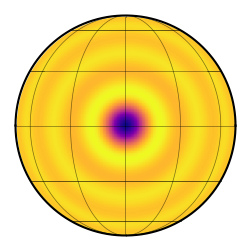

In [11]:
map.show()

In [12]:
er = np.array([
    0.99657637,
    0.0, -0.00436468, 0.0,
    0.0, 0.0, -0.00531181, 0.0, 0.0,
    0.0, 0.0, 0.0, -0.00344001, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, -0.00395098, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, -0.00175227, 0.0, 0.0, 0.0, 0.0, 0.0
])

In [13]:
N = (lmax + 1)**2
Er = np.zeros((N, N))

for l in range(lmax + 1):
    for lp in range(lmax + 1):
        Er[l**2 + l, lp**2 + lp] = er[l**2 + l] * er[lp**2 + lp]

In [14]:
class FixedER:
    def __init__(self, er, lmax):
        self.er = np.asarray(er, dtype=float)
        self.lmax = lmax
        self.N = (lmax + 1)**2

        self.eigEr = np.zeros((self.N, 1), dtype=float)

        for l in range(lmax + 1):
            i = l**2 + l  
            self.eigEr[i, 0] = self.er[i]

    def first_moment(self):
        return self.er

    def second_moment(self):
        return self.eigEr

In [15]:
S = FixedER(er, lmax)

I_lat = LatitudeIntegral(a, b, child=S, ydeg=lmax)

ephi = I_lat.first_moment().eval()

eigEphi = I_lat.second_moment().eval()
Ephi = eigEphi @ eigEphi.T

draw 1000 samples from SP, calculate the pixel variance and the ylm variance between the samples, 

In [52]:
sp.sample_ylm(nsamples=nsamples).eval()

array([[-0.10509577,  0.03314623,  0.02658103, ...,  0.01751334,
        -0.06407323, -0.00421399],
       [-0.10509742,  0.00473698, -0.05474322, ...,  0.07136456,
         0.04422093,  0.04174122],
       [-0.10509627, -0.00401794,  0.02738597, ...,  0.08786793,
        -0.0078695 , -0.03198048],
       ...,
       [-0.10509854, -0.02918601, -0.00773886, ...,  0.06733288,
        -0.05503204,  0.06721218],
       [-0.10509874, -0.00186791,  0.02360886, ...,  0.01799072,
         0.02014103,  0.06432701],
       [-0.10509709,  0.00224745,  0.0437913 , ...,  0.03294303,
         0.00647538, -0.072419  ]])

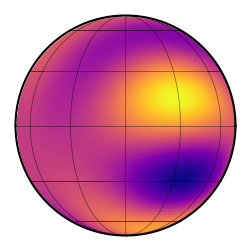

Compiling `RAxisAngle`... Done.
Compiling `pT`... Done.


In [59]:
nsamples = 1000

ys = sp.sample_ylm(nsamples=nsamples).eval()

ys = np.asarray(ys)

ylm_mean = np.mean(ys, axis=0)
ylm_var = np.var(ys, axis=0)

map[:,:] = ylm_var
map.show()

lat, lon, Y2P, P2Y, Dx, Dy = map.get_pixel_transforms(
    oversample=2,
    lam=1e-6,
    eps=1e-6
)

Y2P = np.asarray(Y2P)
p_samples = ys @ Y2P.T

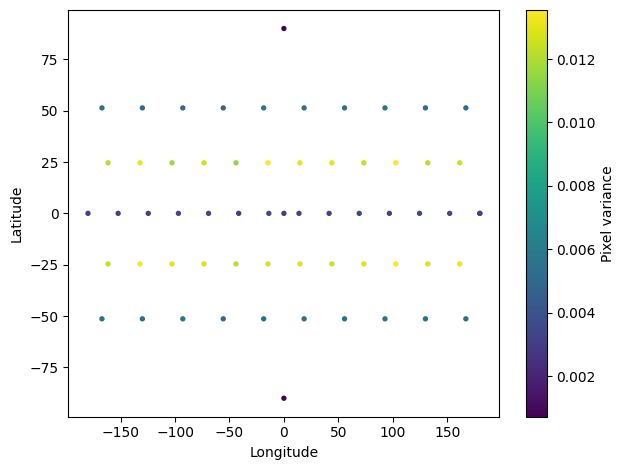

In [66]:
pix_mean = p_samples.mean(axis=0)
pix_var = p_samples.var(axis=0)

plt.scatter(lon, lat, c=pix_var, s=8)
plt.colorbar(label="Pixel variance")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [16]:
ephi

array([ 9.96576370e-01,  0.00000000e+00, -3.77992376e-03,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -3.40392283e-03,  0.00000000e+00,
        1.10151917e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.34178268e-03,  0.00000000e+00,  1.26828846e-03,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -6.88361147e-04,  0.00000000e+00,  1.86043549e-03,  0.00000000e+00,
       -2.48092686e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -4.83530673e-05,  0.00000000e+00,
        8.63997019e-04,  0.00000000e+00, -2.44006693e-04,  0.00000000e+00])

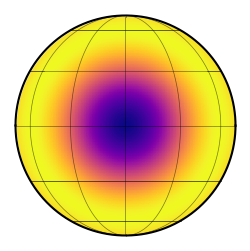

In [17]:
map[:,:] = er
map.show()

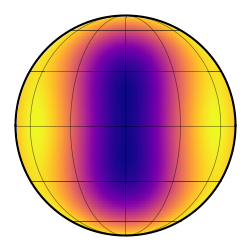

In [18]:
map[:,:] = ephi
map.show()

In [19]:
I_long = LongitudeIntegral(child=I_lat, ydeg=lmax)

In [20]:
elambda = I_long.first_moment().eval()

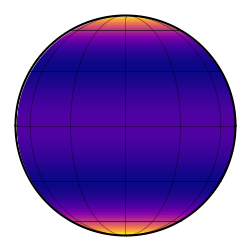

In [21]:
map[:,:] = elambda
map.show()

In [22]:
elambda

array([ 9.96576370e-01,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -3.74008914e-04,  0.00000000e+00,
       -6.47802441e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        2.24404728e-04,  0.00000000e+00,  3.34522818e-04,  0.00000000e+00,
        4.42532092e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -1.60250277e-20,  0.00000000e+00,
       -2.73293957e-20,  0.00000000e+00,  6.83232695e-21,  0.00000000e+00])

In [23]:
np.log(Ephi.conj().T)

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_1137/2742142832.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(Ephi.conj().T)
/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_1137/2742142832.py:1: RuntimeWarning: invalid value encountered in log
  np.log(Ephi.conj().T)


array([[-6.85900806e-03,             nan,             nan, ...,
                   -inf,             nan,            -inf],
       [            nan, -1.22978221e+01,             nan, ...,
                   -inf, -4.51317196e+01,            -inf],
       [            nan,             nan, -1.11421372e+01, ...,
                   -inf, -1.40290925e+01,            -inf],
       ...,
       [           -inf,            -inf,            -inf, ...,
                   -inf,            -inf,            -inf],
       [            nan, -4.51317196e+01, -1.40290925e+01, ...,
                   -inf, -1.58845749e+01,            -inf],
       [           -inf,            -inf,            -inf, ...,
                   -inf,            -inf,            -inf]])

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_1137/1566870390.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(Ephi.conj().T))
/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_1137/1566870390.py:1: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(Ephi.conj().T))


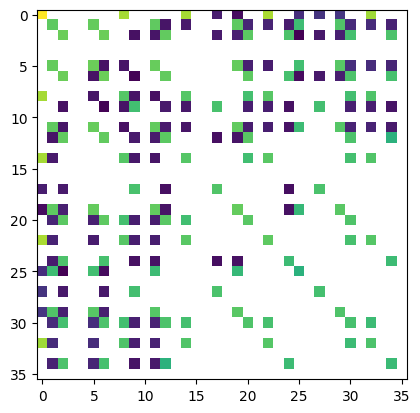

In [24]:
plt.imshow(np.log(Ephi.conj().T))

In [25]:
Ephi

array([[ 9.93164461e-01, -2.70617036e-19, -3.76698270e-03, ...,
         0.00000000e+00, -2.43171304e-04,  0.00000000e+00],
       [-2.70617036e-19,  4.56166842e-06, -8.34159675e-21, ...,
         0.00000000e+00,  2.50924586e-20,  0.00000000e+00],
       [-3.76698270e-03, -8.34159675e-21,  1.44887631e-05, ...,
         0.00000000e+00,  8.07685973e-07,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-2.43171304e-04,  2.50924586e-20,  8.07685973e-07, ...,
         0.00000000e+00,  1.26303909e-07,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

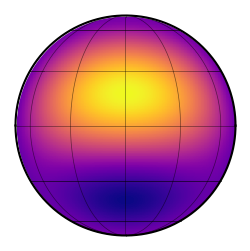

In [26]:
map[:,:] = np.diag(Ephi)
map.show()

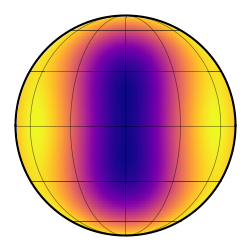

In [27]:
map[:,:] = Ephi[:,0]
map.show()

In [28]:
Ephi

array([[ 9.93164461e-01, -2.70617036e-19, -3.76698270e-03, ...,
         0.00000000e+00, -2.43171304e-04,  0.00000000e+00],
       [-2.70617036e-19,  4.56166842e-06, -8.34159675e-21, ...,
         0.00000000e+00,  2.50924586e-20,  0.00000000e+00],
       [-3.76698270e-03, -8.34159675e-21,  1.44887631e-05, ...,
         0.00000000e+00,  8.07685973e-07,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-2.43171304e-04,  2.50924586e-20,  8.07685973e-07, ...,
         0.00000000e+00,  1.26303909e-07,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [29]:
I_lon = LongitudeIntegral(child=I_lat, ydeg=lmax)

elambda = I_lon.first_moment().eval()

eigElambda = I_lon.second_moment().eval()
Elambda = eigElambda @ eigElambda.T

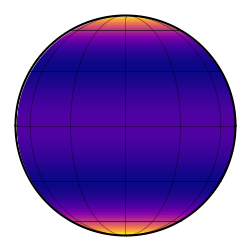

In [30]:
map[:,:] = elambda
map.show()

In [31]:
elambda

array([ 9.96576370e-01,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -3.74008914e-04,  0.00000000e+00,
       -6.47802441e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        2.24404728e-04,  0.00000000e+00,  3.34522818e-04,  0.00000000e+00,
        4.42532092e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -1.60250277e-20,  0.00000000e+00,
       -2.73293957e-20,  0.00000000e+00,  6.83232695e-21,  0.00000000e+00])

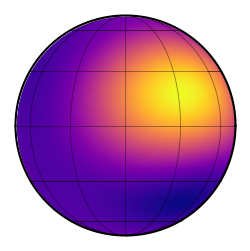

In [32]:
map[:,:] = np.diag(Elambda)
map.show()

In [33]:
Elambda

array([[ 9.93164461e-01, -2.15387047e-19,  6.71694166e-19, ...,
         2.63695507e-20,  4.59187787e-19,  1.05120971e-20],
       [-2.15387047e-19,  4.56166842e-06, -1.90164089e-21, ...,
        -1.01476543e-21, -1.45467098e-22, -3.57342503e-21],
       [ 6.71694166e-19, -1.90164089e-21,  7.24438154e-06, ...,
         6.33993194e-20, -4.27780804e-07,  1.09890481e-20],
       ...,
       [ 2.63695507e-20, -1.01476543e-21,  6.33993194e-20, ...,
         2.58341447e-07,  3.49235306e-20, -2.19461423e-08],
       [ 4.59187787e-19, -1.45467098e-22, -4.27780804e-07, ...,
         3.49235306e-20,  2.47653452e-07,  2.79307668e-21],
       [ 1.05120971e-20, -3.57342503e-21,  1.09890481e-20, ...,
        -2.19461423e-08,  2.79307668e-21,  2.18209612e-07]])

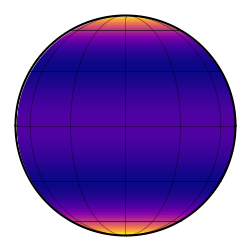

In [34]:
map[:,:] = Elambda[:,0]
map.show()

In [35]:
variance_matrix = Elambda - elambda[:, None] * elambda[None, :]

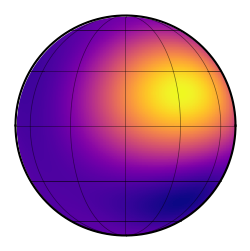

In [36]:
map[:,:] = np.diag(variance_matrix)
map.show()

In [37]:
np.diag(variance_matrix)

array([-3.33066907e-16,  4.56166842e-06,  7.24438154e-06,  7.24438154e-06,
        6.54063749e-06,  6.54063749e-06,  5.24663099e-06,  6.41200414e-06,
        2.91588470e-06,  1.88912327e-06,  2.37277999e-06,  2.08258596e-06,
        1.49061184e-06,  1.78640419e-06,  1.25397795e-06,  9.58185601e-07,
        1.60230852e-06,  2.12994025e-06,  2.50682005e-06,  1.97918833e-06,
        1.50755169e-06,  1.73651282e-06,  1.37126549e-06,  1.36737091e-06,
        1.05118726e-06,  2.32595369e-07,  2.88327353e-07,  3.61577426e-07,
        3.92539639e-07,  2.99006987e-07,  2.56381024e-07,  2.71650630e-07,
        2.44167214e-07,  2.58341447e-07,  2.47653452e-07,  2.18209612e-07])

Pre-computing some matrices... Done.
Compiling `RAxisAngle`... Done.
Compiling `pT`... Done.


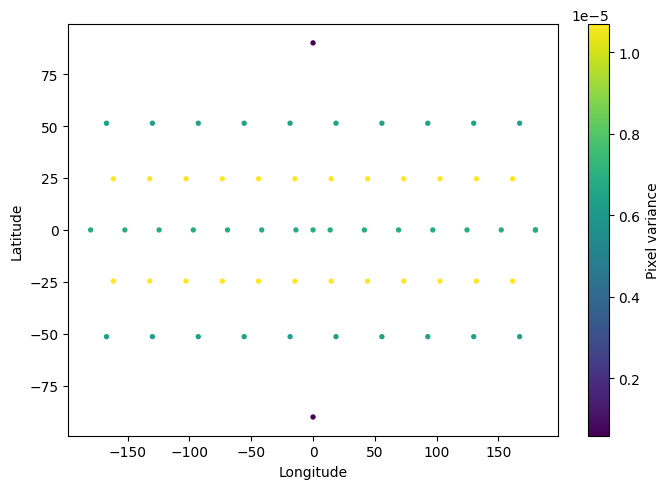

In [38]:
m = starry.Map(ydeg=lmax)

lat, lon, Y2P, P2Y, Dx, Dy = m.get_pixel_transforms(
    oversample=2,
    lam=1e-6,
    eps=1e-6
)

Y2P = np.asarray(Y2P)

pix_mean = Y2P @ elambda

Epix = Y2P @ Elambda @ Y2P.T

pix_var = np.diag(Epix) - pix_mean**2

plt.figure(figsize=(7, 5))
plt.scatter(lon, lat, c=pix_var, s=8)
plt.colorbar(label="Pixel variance")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [39]:
sp.cov_ylm.eval()

array([[ 9.99999955e-13,  3.11303192e-20, -3.89618859e-20, ...,
        -8.65095399e-21, -1.48414025e-19, -3.44845063e-21],
       [ 3.11303192e-20,  5.88088608e-05,  3.09210793e-20, ...,
         2.65682415e-21, -4.95474114e-21,  6.05231882e-22],
       [-3.89618859e-20,  3.09210793e-20,  9.33942987e-05, ...,
        -1.36019740e-20, -4.77825556e-05,  8.52991788e-20],
       ...,
       [-8.65095399e-21,  2.65682415e-21, -1.36019740e-20, ...,
         2.50017959e-04, -1.40904667e-19, -2.12390607e-05],
       [-1.48414025e-19, -4.95474114e-21, -4.77825556e-05, ...,
        -1.40904667e-19,  2.39674320e-04,  1.63848639e-19],
       [-3.44845063e-21,  6.05231882e-22,  8.52991788e-20, ...,
        -2.12390607e-05,  1.63848639e-19,  2.11179130e-04]])

In [40]:
sp.mean_ylm.eval()

array([-1.05097770e-02,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -1.82354133e-03,  0.00000000e+00,
       -3.15846623e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        3.22018536e-03,  0.00000000e+00,  4.80036892e-03,  0.00000000e+00,
        6.35029118e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -4.98525465e-19,  0.00000000e+00,
       -8.50195080e-19,  0.00000000e+00,  2.12548086e-19,  0.00000000e+00])

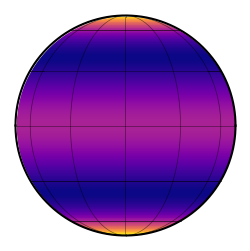

In [41]:
map[:,:] = sp.mean_ylm.eval()
map.show()

In [8]:
alpha = 5*np.sqrt(3)
beta = 10-alpha
lmax = 30

r = np.rad2deg(0.1)
c = 0.5

a, b = alpha_beta_to_ab(alpha, beta)

sp = starry_process.StarryProcess(a=a, b=b, r=r, c=c, n=1, ydeg=lmax)

mean = sp.mean_ylm.eval()
cov  = sp.cov_ylm.eval()

In [9]:
mean = sp.mean_ylm.eval()
cov  = sp.cov_ylm.eval()

In [23]:
mean

array([-3.84309523e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -5.90221487e-04,  0.00000000e+00,
       -1.02229360e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        6.02725550e-04,  0.00000000e+00,  8.98490200e-04,  0.00000000e+00,
        1.18859081e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -1.02965811e-19,  0.00000000e+00,
       -1.75599908e-19,  0.00000000e+00,  4.38998357e-20,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  4.57786874e-04,  0.00000000e+00,
        6.63396206e-04,  0.00000000e+00,  7.26714133e-04,  0.00000000e+00,
        9.83975588e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  

In [24]:
map[:,:] = mean
map.show()

ERROR (theano.graph.opt): Optimization failure due to: constant_folding
ERROR (theano.graph.opt): node: AdvancedIncSubtensor1{no_inplace,set}(TensorConstant{[1.0000000..00248e+07]}, TensorConstant{[-3.843095..34087e-06]}, TensorConstant{[  0   1  ..3 254 255]})
ERROR (theano.graph.opt): TRACEBACK:
ERROR (theano.graph.opt): Traceback (most recent call last):
  File "/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/theano/graph/opt.py", line 2017, in process_node
    replacements = lopt.transform(fgraph, node)
  File "/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/theano/graph/opt.py", line 1209, in transform
    return self.fn(*args, **kwargs)
  File "/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/theano/tensor/opt.py", line 7010, in constant_folding
    required = thunk()
  File "/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/theano/graph/op.py", line 606, in rval
    thunk()
  File "/Users/sabina/min

ValueError: array is not broadcastable to correct shape

In [25]:
cov

array([[ 1.32022883e-11, -2.79806288e-11, -4.25381386e-11, ...,
         7.99787826e-10,  2.89043023e-14,  1.12153831e-09],
       [-2.79806288e-11,  1.04433836e-05,  7.54745247e-11, ...,
        -3.89397275e-08,  4.12847156e-11, -5.46074172e-08],
       [-4.25381386e-11,  7.54745247e-11,  1.65848570e-05, ...,
         3.56293009e-12, -2.49082992e-12,  1.07996439e-10],
       ...,
       [ 7.99787826e-10, -3.89397275e-08,  3.56293009e-12, ...,
         2.27729511e+05,  1.56857685e-03,  2.11110072e+05],
       [ 2.89043023e-14,  4.12847156e-11, -2.49082992e-12, ...,
         1.56857685e-03,  3.01086079e+05, -2.04542677e-04],
       [ 1.12153831e-09, -5.46074172e-08,  1.07996439e-10, ...,
         2.11110072e+05, -2.04542677e-04,  5.97142541e+05]])

In [26]:
map[:,:] = np.diag(cov)
map.show()

ERROR (theano.graph.opt): Optimization failure due to: constant_folding
ERROR (theano.graph.opt): node: AdvancedIncSubtensor1{no_inplace,set}(TensorConstant{[1.0000000..00248e+07]}, TensorConstant{[-3.843095..34087e-06]}, TensorConstant{[  0   1  ..3 254 255]})
ERROR (theano.graph.opt): TRACEBACK:
ERROR (theano.graph.opt): Traceback (most recent call last):
  File "/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/theano/graph/opt.py", line 2017, in process_node
    replacements = lopt.transform(fgraph, node)
  File "/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/theano/graph/opt.py", line 1209, in transform
    return self.fn(*args, **kwargs)
  File "/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/theano/tensor/opt.py", line 7010, in constant_folding
    required = thunk()
  File "/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/theano/graph/op.py", line 606, in rval
    thunk()
  File "/Users/sabina/min

ValueError: array is not broadcastable to correct shape

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_62411/282266317.py:1: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(cov))


Text(0.5, 1.0, 'starry process')

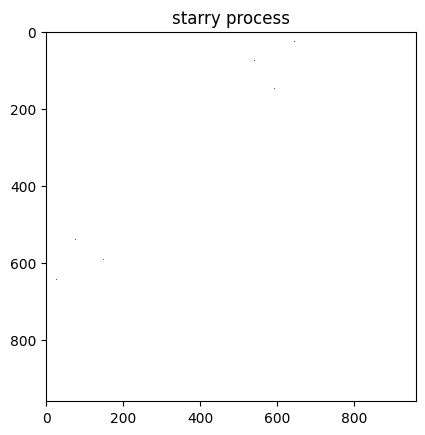

In [27]:
plt.imshow(np.log10(cov))
plt.title('starry process')

In [19]:
np.log10(cov)

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_62411/2270484336.py:1: RuntimeWarning: invalid value encountered in log10
  np.log10(cov)


array([[-11.99999998, -20.73845819, -19.72162124, ...,          nan,
        -17.67682051, -20.69458361],
       [-20.73845819,  -4.85957811, -20.67473599, ..., -21.48064853,
                 nan, -20.92931594],
       [-19.72162124, -20.67473599,  -4.65870052, ...,          nan,
                 nan, -17.49198199],
       ...,
       [         nan, -21.48064853,          nan, ...,  -4.92107625,
                 nan,          nan],
       [-17.67682051,          nan,          nan, ...,          nan,
         -4.95461382, -14.33253307],
       [-20.69458361, -20.92931594, -17.49198199, ...,          nan,
        -14.33253307,  -4.99438948]])

In [49]:
mean_c = ContrastIntegral(child=I_lon, ydeg=lmax, c=c, n=n).mean().eval()

In [50]:
cov_c = ContrastIntegral(child=I_lon, ydeg=lmax, c=c, n=n)._cov.eval()

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_1137/3188744963.py:1: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(cov_c))


Text(0.5, 1.0, 'starry process')

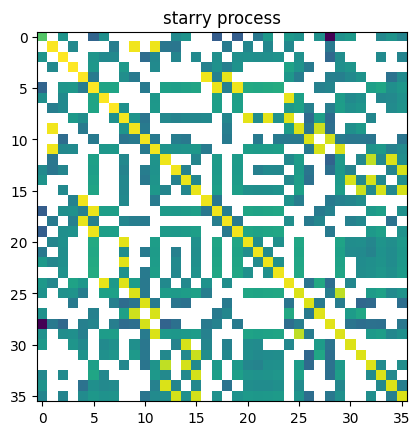

In [51]:
plt.imshow(np.log10(cov_c))
plt.title('starry process')

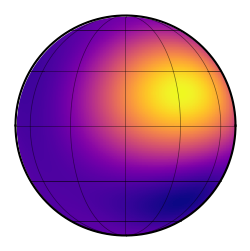

In [52]:
map[:,:] = np.diag(cov_c)
map.show()

In [53]:
cov_c

array([[ 9.99308780e-13, -5.31446238e-19,  1.65733892e-18, ...,
         6.50642583e-20,  1.11620008e-18,  2.59375599e-20],
       [-5.31446238e-19,  1.12554667e-05, -4.69211082e-21, ...,
        -2.50383335e-21, -3.58925677e-22, -8.81707285e-21],
       [ 1.65733892e-18, -4.69211082e-21,  1.78747960e-05, ...,
         1.56431550e-19, -1.05550683e-06,  2.71143893e-20],
       ...,
       [ 6.50642583e-20, -2.50383335e-21,  1.56431550e-19, ...,
         6.37432971e-07,  8.61703577e-20, -5.41499357e-08],
       [ 1.11620008e-18, -3.58925677e-22, -1.05550683e-06, ...,
         8.61703577e-20,  6.11061400e-07,  6.89164048e-21],
       [ 2.59375599e-20, -8.81707285e-21,  2.71143893e-20, ...,
        -5.41499357e-08,  6.89164048e-21,  5.38411638e-07]])

In [28]:
np.save('sp_cov_ylm_l30.npy', cov)

In [29]:
np.save('sp_mean_ylm_l30.npy', mean)

In [70]:
mean_c

array([ 1.56541850e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -5.87491828e-04,  0.00000000e+00,
       -1.01756569e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        3.52494123e-04,  0.00000000e+00,  5.25467214e-04,  0.00000000e+00,
        6.95127785e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -2.51720547e-20,  0.00000000e+00,
       -4.29289144e-20,  0.00000000e+00,  1.07321941e-20,  0.00000000e+00])

In [11]:
a, b = starry_process.gauss2beta(60, 5)

In [12]:
a,b

(0.3125631150885175, 0.3557450107475467)

In [18]:
starry_process.gauss2beta(20, 5)

(0.4103364775596656, 0.20202777975407832)

In [104]:
truths = [60.0, 5.0]
sp = starry_process.StarryProcess(mu=truths[0], sigma=truths[1], r=20, c=0.1, n=1.0, ydeg=5,normalized=False, marginalize_over_inclination=False,i=90, seed=0)

In [105]:
t = np.linspace(0, 4, 500)
flux = sp.sample(t, nsamples=1).eval()
flux.shape

(1, 500)

In [106]:
flux[0]

array([ 1.31943346e-02,  1.31121594e-02,  1.30850709e-02,  1.29845942e-02,
        1.29513273e-02,  1.26501151e-02,  1.25791199e-02,  1.24226026e-02,
        1.21916744e-02,  1.21324710e-02,  1.19029087e-02,  1.17919564e-02,
        1.15783938e-02,  1.13436268e-02,  1.10580009e-02,  1.09397930e-02,
        1.04346851e-02,  1.02800446e-02,  9.87494842e-03,  9.62450352e-03,
        9.23056888e-03,  8.90246426e-03,  8.29669444e-03,  7.91090250e-03,
        7.32322461e-03,  6.84034912e-03,  6.13946078e-03,  5.70146749e-03,
        4.84437007e-03,  4.28048092e-03,  3.81865739e-03,  3.18650609e-03,
        2.28210676e-03,  1.74339931e-03,  9.44151806e-04,  1.95118122e-04,
       -6.15924276e-04, -1.34703967e-03, -2.08949941e-03, -2.57536088e-03,
       -3.44105808e-03, -4.38653166e-03, -5.03318121e-03, -5.63065505e-03,
       -6.45049052e-03, -7.14434455e-03, -7.64325867e-03, -8.24223796e-03,
       -8.78168625e-03, -9.40343779e-03, -1.00350777e-02, -1.07318555e-02,
       -1.10256244e-02, -

In [107]:
sp.mean_ylm.eval()

array([-1.02018927e-02,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  6.47905676e-03,  0.00000000e+00,
        1.12220555e-02,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -2.38573912e-04,  0.00000000e+00, -3.55644989e-04,  0.00000000e+00,
       -4.70474099e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  4.93687993e-19,  0.00000000e+00,
        8.72366975e-20,  0.00000000e+00, -1.06826954e-20,  0.00000000e+00])

Pre-computing some matrices... Done.
Compiling `render`... Done.


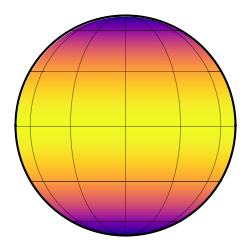

In [108]:
map = starry.Map(ydeg=5)
map[:,:] = sp.mean_ylm.eval()
map.show()

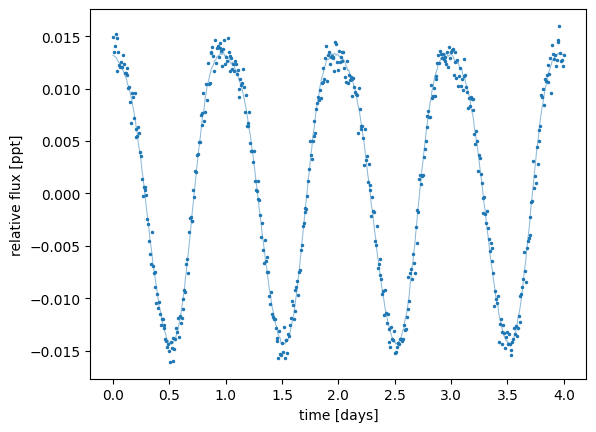

In [109]:
ferr = 1e-3
np.random.seed(0)
f = flux + ferr * np.random.randn(1, len(t))
plt.plot(t, flux[0], "C0-", lw=0.75, alpha=0.5)
plt.plot(t, f[0], "C0.", ms=3)
plt.xlabel("time [days]")
plt.ylabel("relative flux [ppt]")
plt.show()

In [110]:
np.save("flux_obs_latitude_tutorial.npy", f)

In [111]:
sp.mean(t,i=90,p=1).eval()

array([-0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00

In [112]:
sp.cov(t,i=90,p=1).eval()

array([[5.22859782e-05, 5.21963730e-05, 5.19280391e-05, ...,
        5.19280391e-05, 5.21963730e-05, 5.22859782e-05],
       [5.21963730e-05, 5.22859782e-05, 5.21963730e-05, ...,
        5.14824184e-05, 5.19280391e-05, 5.21963730e-05],
       [5.19280391e-05, 5.21963730e-05, 5.22859782e-05, ...,
        5.08619001e-05, 5.14824184e-05, 5.19280391e-05],
       ...,
       [5.19280391e-05, 5.14824184e-05, 5.08619001e-05, ...,
        5.22859782e-05, 5.21963730e-05, 5.19280391e-05],
       [5.21963730e-05, 5.19280391e-05, 5.14824184e-05, ...,
        5.21963730e-05, 5.22859782e-05, 5.21963730e-05],
       [5.22859782e-05, 5.21963730e-05, 5.19280391e-05, ...,
        5.19280391e-05, 5.21963730e-05, 5.22859782e-05]])

In [113]:
tt.dot(sp._flux.design_matrix(t,i=90,p=1, u=(0,0)).eval(),sp.mean_ylm.eval()).eval()

array([-0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00655017,
       -0.00655017, -0.00655017, -0.00655017, -0.00655017, -0.00

In [114]:
sp._flux.design_matrix(t,i=90,p=1, u=(0,0)).eval()

array([[ 1.00000000e+00,  0.00000000e+00,  1.15470054e+00, ...,
         0.00000000e+00, -1.11022302e-16,  0.00000000e+00],
       [ 1.00000000e+00,  8.12842541e-20,  1.15323625e+00, ...,
        -1.10877210e-17, -1.10057799e-16,  8.81554149e-18],
       [ 1.00000000e+00,  3.24930862e-19,  1.14884710e+00, ...,
        -1.76029656e-17, -1.07416156e-16,  1.74841691e-17],
       ...,
       [ 1.00000000e+00,  3.24930862e-19,  1.14884710e+00, ...,
         1.76029656e-17, -1.07416156e-16, -1.74841691e-17],
       [ 1.00000000e+00,  8.12842541e-20,  1.15323625e+00, ...,
         1.10877210e-17, -1.10057799e-16, -8.81554149e-18],
       [ 1.00000000e+00,  0.00000000e+00,  1.15470054e+00, ...,
         0.00000000e+00, -1.11022302e-16,  0.00000000e+00]])

In [115]:
flux[0]

array([ 1.31943346e-02,  1.31121594e-02,  1.30850709e-02,  1.29845942e-02,
        1.29513273e-02,  1.26501151e-02,  1.25791199e-02,  1.24226026e-02,
        1.21916744e-02,  1.21324710e-02,  1.19029087e-02,  1.17919564e-02,
        1.15783938e-02,  1.13436268e-02,  1.10580009e-02,  1.09397930e-02,
        1.04346851e-02,  1.02800446e-02,  9.87494842e-03,  9.62450352e-03,
        9.23056888e-03,  8.90246426e-03,  8.29669444e-03,  7.91090250e-03,
        7.32322461e-03,  6.84034912e-03,  6.13946078e-03,  5.70146749e-03,
        4.84437007e-03,  4.28048092e-03,  3.81865739e-03,  3.18650609e-03,
        2.28210676e-03,  1.74339931e-03,  9.44151806e-04,  1.95118122e-04,
       -6.15924276e-04, -1.34703967e-03, -2.08949941e-03, -2.57536088e-03,
       -3.44105808e-03, -4.38653166e-03, -5.03318121e-03, -5.63065505e-03,
       -6.45049052e-03, -7.14434455e-03, -7.64325867e-03, -8.24223796e-03,
       -8.78168625e-03, -9.40343779e-03, -1.00350777e-02, -1.07318555e-02,
       -1.10256244e-02, -

In [116]:
from starry_process.compat import random_normal

U = random_normal(sp.random, (len(t), 1))
U = U.eval()

In [127]:
np.save("U_random.npy", U)

In [118]:
from starry_process.math import cho_factor

Sigma = sp.cov(t, i=90, p=1).eval()         
eps = 1e-8                                    
cho_cov = cho_factor(Sigma + eps * np.eye(len(t)))

cho_cov.eval()

array([[ 7.23159583e-03,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 7.21782221e-03,  4.46117514e-04,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 7.18071644e-03,  8.23187481e-04,  2.35906658e-04, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 7.18071644e-03, -7.77185903e-04, -2.58656980e-04, ...,
         1.00718268e-04,  0.00000000e+00,  0.00000000e+00],
       [ 7.21782221e-03, -3.78640839e-04, -1.48464842e-04, ...,
         1.42086631e-06,  1.00708245e-04,  0.00000000e+00],
       [ 7.23021301e-03,  2.23729247e-05, -3.59780800e-05, ...,
         1.38897232e-06,  1.40081228e-06,  1.00698353e-04]])

In [125]:
flux_ = tt.transpose(sp.mean(t,i=90,p=1).eval()[:, None] + tt.dot(cho_cov, U)).eval()

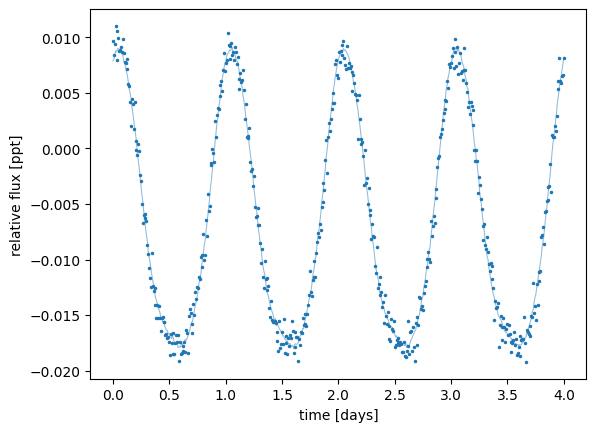

In [126]:
ferr = 1e-3
np.random.seed(0)
f = flux_ + ferr * np.random.randn(1, len(t))
plt.plot(t, flux_[0], "C0-", lw=0.75, alpha=0.5)
plt.plot(t, f[0], "C0.", ms=3)
plt.xlabel("time [days]")
plt.ylabel("relative flux [ppt]")
plt.show()

In [128]:
truths = [60.0, 5.0]
sp = starry_process.StarryProcess(mu=truths[0], sigma=truths[1], r=20, c=0.1, n=1.0, ydeg=5,normalized=False, marginalize_over_inclination=True, seed=0)

In [129]:
t = np.linspace(0, 4, 500)
flux = sp.sample(t, nsamples=1).eval()
flux.shape

(1, 500)

In [130]:
sp.mean_ylm.eval()

array([-1.02018927e-02,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  6.47905676e-03,  0.00000000e+00,
        1.12220555e-02,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -2.38573912e-04,  0.00000000e+00, -3.55644989e-04,  0.00000000e+00,
       -4.70474099e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  4.93687993e-19,  0.00000000e+00,
        8.72366975e-20,  0.00000000e+00, -1.06826954e-20,  0.00000000e+00])

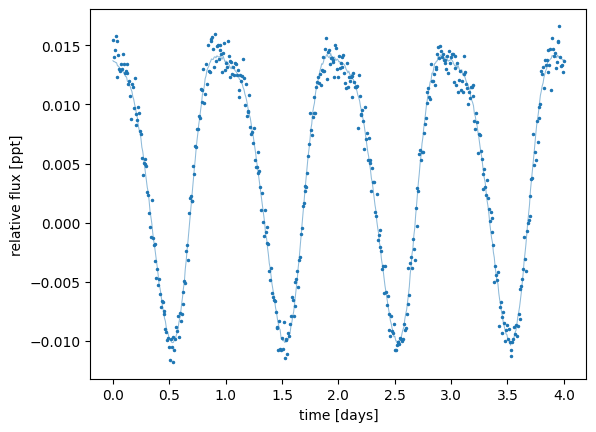

In [131]:
ferr = 1e-3
np.random.seed(0)
f = flux + ferr * np.random.randn(1, len(t))
plt.plot(t, flux[0], "C0-", lw=0.75, alpha=0.5)
plt.plot(t, f[0], "C0.", ms=3)
plt.xlabel("time [days]")
plt.ylabel("relative flux [ppt]")
plt.show()

In [132]:
sp.mean(t,p=1).eval()

array([-0.01020189, -0.01020189, -0.01020189, -0.01020189, -0.01020189,
       -0.01020189, -0.01020189, -0.01020189, -0.01020189, -0.01020189,
       -0.01020189, -0.01020189, -0.01020189, -0.01020189, -0.01020189,
       -0.01020189, -0.01020189, -0.01020189, -0.01020189, -0.01020189,
       -0.01020189, -0.01020189, -0.01020189, -0.01020189, -0.01020189,
       -0.01020189, -0.01020189, -0.01020189, -0.01020189, -0.01020189,
       -0.01020189, -0.01020189, -0.01020189, -0.01020189, -0.01020189,
       -0.01020189, -0.01020189, -0.01020189, -0.01020189, -0.01020189,
       -0.01020189, -0.01020189, -0.01020189, -0.01020189, -0.01020189,
       -0.01020189, -0.01020189, -0.01020189, -0.01020189, -0.01020189,
       -0.01020189, -0.01020189, -0.01020189, -0.01020189, -0.01020189,
       -0.01020189, -0.01020189, -0.01020189, -0.01020189, -0.01020189,
       -0.01020189, -0.01020189, -0.01020189, -0.01020189, -0.01020189,
       -0.01020189, -0.01020189, -0.01020189, -0.01020189, -0.01